In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Filter for Data Scientist data
df_DE = df[df['job_title_short'] == 'Data Engineer'].copy()

c:\Users\HomePC\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
df_DE_Canada = df[(df['job_title_short'] =='Data Engineer') & (df['job_country'] =='Canada')].copy()

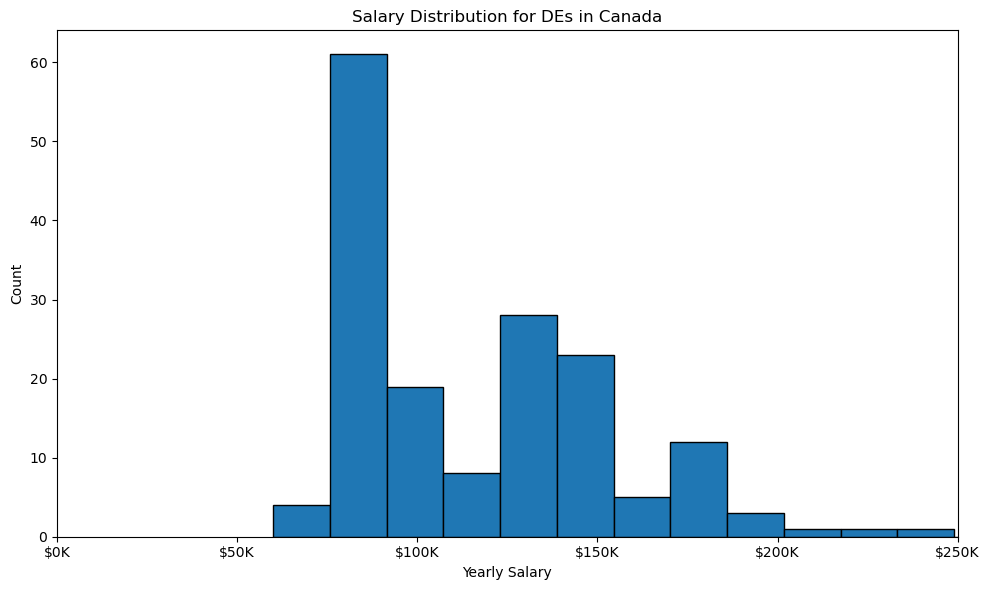

In [34]:
import matplotlib.ticker as mticker

df_DE_Canada['salary_year_avg'].plot(
    kind ='hist',
    bins=20,
    edgecolor ='black',
    figsize=(10, 6)
)
plt.xlim(0,250000)

ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'${int(x/1000):,}K'))


plt.xlabel('Yearly Salary')
plt.ylabel('Count')
plt.title('Salary Distribution for DEs in Canada')
plt.tight_layout()
plt.show()